# Comtrade Performance Analytics
## Demand Volatility and Logistics Bottleneck Analysis
### Indonesia's Electrical Machinery Trade (HS Chapter 85), 2015-2024

**Data Sources**
- UN Comtrade: Monthly merchandise trade statistics, Indonesia (reporter), HS Chapter 85
- World Bank Logistics Performance Index (LPI): 2007-2022, forward-filled to annual frequency

**Scope**
This analysis examines Indonesia's export and import trade flows in electrical machinery
and equipment across seven key trading partners: China, Japan, Singapore, the United States,
Germany, Malaysia, and South Korea. The data covers January 2015 through December 2024,
spanning pre-pandemic, COVID-shock, and post-pandemic recovery periods.

**Analytical Objectives**
1. Characterize long-run trade flow trends and structural shifts in partner composition
2. Quantify demand volatility and identify anomalous periods
3. Assess logistics bottlenecks by correlating partner LPI scores with bilateral trade volumes
4. Derive data-driven recommendations for supply chain risk management


## 0. Setup and Configuration

In [20]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# Global plot styling
plt.rcParams.update({
    "figure.dpi"        : 130,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.grid"         : True,
    "grid.color"        : "#e0e0e0",
    "grid.linewidth"    : 0.6,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "font.size"         : 10,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 10,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 9,
    "legend.framealpha" : 0.8,
})

# Consistent categorical palette for 7 partners
PARTNER_COLORS = {
    "China"         : "#cf3711",
    "Japan"         : "#f893eb",
    "Singapore"     : "#74c69d",
    "United States" : "#1e6091",
    "Germany"       : "#fdd936",
    "Malaysia"      : "#a8dadc",
    "South Korea"   : "#e76f51",
    "World"         : "#adb5bd"
}

COVID_START = "2019-12-01"
COVID_END   = "2021-06-01"

def billions(x, pos):
    if abs(x) >= 1e9:
        return f"${x/1e9:.1f}B"
    elif abs(x) >= 1e6:
        return f"${x/1e6:.0f}M"
    return f"${x:.0f}"

print("Setup complete.")


Setup complete.


## 1. Data Overview

In [21]:
# Load processed datasets
trade   = pd.read_csv("../data/processed/comtrade_features.csv", parse_dates=["date"])
balance = pd.read_csv("../data/processed/trade_balance.csv")
lpi_m   = pd.read_csv("../data/processed/lpi_trade_merged.csv")
lpi     = pd.read_csv("../data/processed/lpi_annual_clean.csv")
world   = pd.read_csv("../data/processed/comtrade_hs85_world.csv", parse_dates=["date"])

print("=== comtrade_features ===")
print(f"Shape       : {trade.shape}")
print(f"Date range  : {trade['date'].min().date()} to {trade['date'].max().date()}")
print(f"Partners    : {sorted(trade['partner_name'].unique())}")
print(f"Flows       : {trade['flow_label'].unique()}")
print(f"Anomalies   : {trade['is_anomaly'].sum()} of {len(trade)} rows ({trade['is_anomaly'].mean()*100:.1f}%)")
print()
print("=== trade_balance ===")
print(f"Shape       : {balance.shape}")
print()
print("=== lpi_trade_merged ===")
print(f"Shape       : {lpi_m.shape}")
print()
print("=== Sample - trade features ===")
trade.head(3)


=== comtrade_features ===
Shape       : (1920, 21)
Date range  : 2015-01-01 to 2024-12-01
Partners    : ['China', 'Germany', 'Japan', 'Malaysia', 'Singapore', 'South Korea', 'United States', 'World']
Flows       : <StringArray>
['exports', 'imports']
Length: 2, dtype: str
Anomalies   : 108 of 1920 rows (5.6%)

=== trade_balance ===
Shape       : (80, 7)

=== lpi_trade_merged ===
Shape       : (140, 13)

=== Sample - trade features ===


,date,year,month,quarter,period,flow_code,flow_label,partner_iso,partner_name,hs_code,...,primary_value_usd,fob_value_usd,cif_value_usd,is_reported,mom_growth,yoy_growth,rolling_3m_avg,rolling_12m_avg,rolling_12m_std,is_anomaly
0,2015-01-01,2015,1,1,201501,X,exports,CHN,China,85,...,33350125.0,33350125.0,0.0,False,NaN,NaN,3.335012e+07,NaN,NaN,False
1,2015-02-01,2015,2,1,201502,X,exports,CHN,China,85,...,22651049.0,22651049.0,0.0,False,-0.320811,NaN,2.800059e+07,NaN,NaN,False
2,2015-03-01,2015,3,1,201503,X,exports,CHN,China,85,...,27697880.0,27697880.0,0.0,False,0.222808,NaN,2.789968e+07,NaN,NaN,False


In [22]:
# Data quality summary
print("=== Null counts - trade features ===")
nulls = trade.isnull().sum()
print(nulls[nulls > 0] if nulls[nulls > 0].any() else "No nulls in core columns.")
print()

# Note: MoM/YoY NaN at start of each group is expected behavior
mom_nulls = trade["mom_growth"].isnull().sum()
yoy_nulls = trade["yoy_growth"].isnull().sum()
print(f"mom_growth NaN: {mom_nulls} (expected - first obs per group has no prior month)")
print(f"yoy_growth NaN: {yoy_nulls} (expected - first 12 months per group have no prior year)")


=== Null counts - trade features ===
fob_value_usd      400
cif_value_usd      400
mom_growth          16
yoy_growth         192
rolling_12m_avg     80
rolling_12m_std     80
dtype: int64

mom_growth NaN: 16 (expected - first obs per group has no prior month)
yoy_growth NaN: 192 (expected - first 12 months per group have no prior year)


## 2. Trade Flow Trends

This section examines how Indonesia's total electrical machinery trade evolved from 2015 to 2024,
first at the aggregate level (all partners combined) and then broken down by partner.


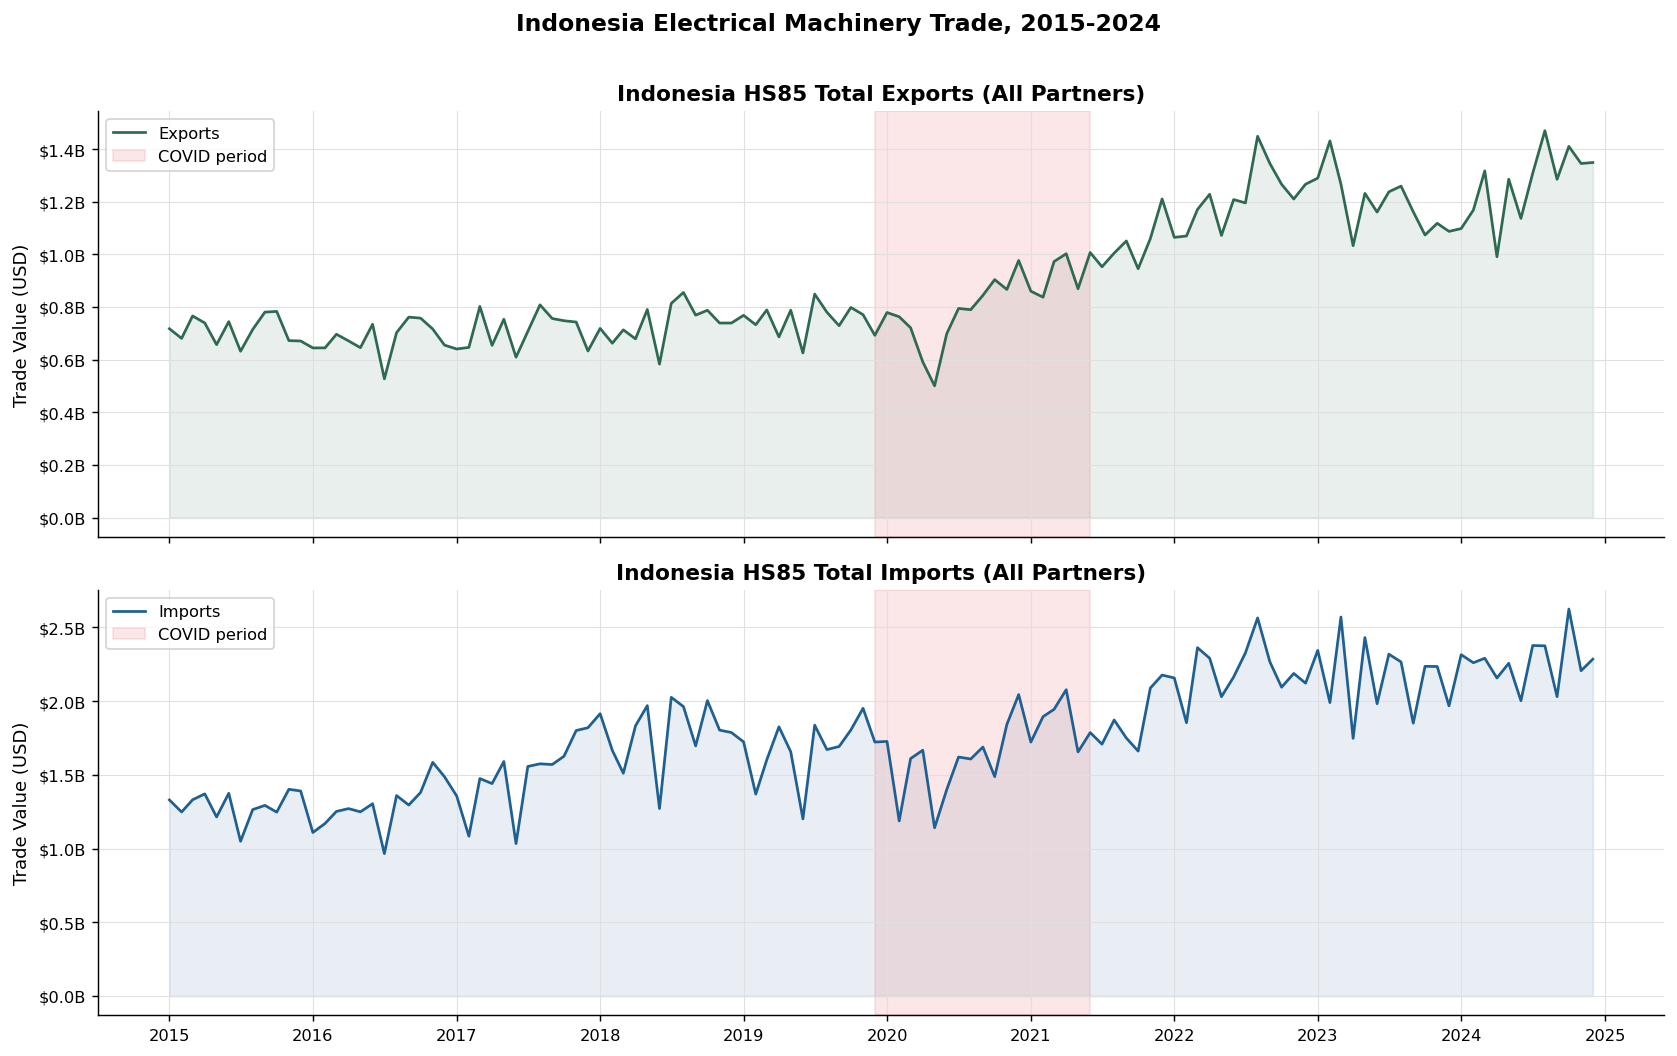

Fig 1 saved.


In [23]:
# World-level monthly trade value
world_clean = world.copy()
world_clean = world_clean.assign(
    date       = pd.to_datetime(world_clean["date"]),
    flow_label = world_clean["flow_label"].str.lower().str.strip()
)

world_monthly = world_clean.groupby(["date", "flow_label"])["primary_value_usd"].sum().reset_index()
exports_w = world_monthly.loc[world_monthly["flow_label"] == "exports"].set_index("date")["primary_value_usd"]
imports_w = world_monthly.loc[world_monthly["flow_label"] == "imports"].set_index("date")["primary_value_usd"]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# -- Exports
ax = axes[0]
ax.plot(exports_w.index, exports_w / 1e9, color="#2d6a4f", linewidth=1.5, label="Exports")
ax.fill_between(exports_w.index, exports_w / 1e9, alpha=0.1, color="#2d6a4f")
ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), alpha=0.12, color="#e63946", label="COVID period")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))
ax.set_title("Indonesia HS85 Total Exports (All Partners)")
ax.set_ylabel("Trade Value (USD)")
ax.legend()

# -- Imports
ax = axes[1]
ax.plot(imports_w.index, imports_w / 1e9, color="#1e6091", linewidth=1.5, label="Imports")
ax.fill_between(imports_w.index, imports_w / 1e9, alpha=0.1, color="#1e6091")
ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), alpha=0.12, color="#e63946", label="COVID period")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))
ax.set_title("Indonesia HS85 Total Imports (All Partners)")
ax.set_ylabel("Trade Value (USD)")
ax.legend()

fig.suptitle("Indonesia Electrical Machinery Trade, 2015-2024", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/fig_01_total_trade_trends.png", bbox_inches="tight")
plt.show()
print("Fig 1 saved.")


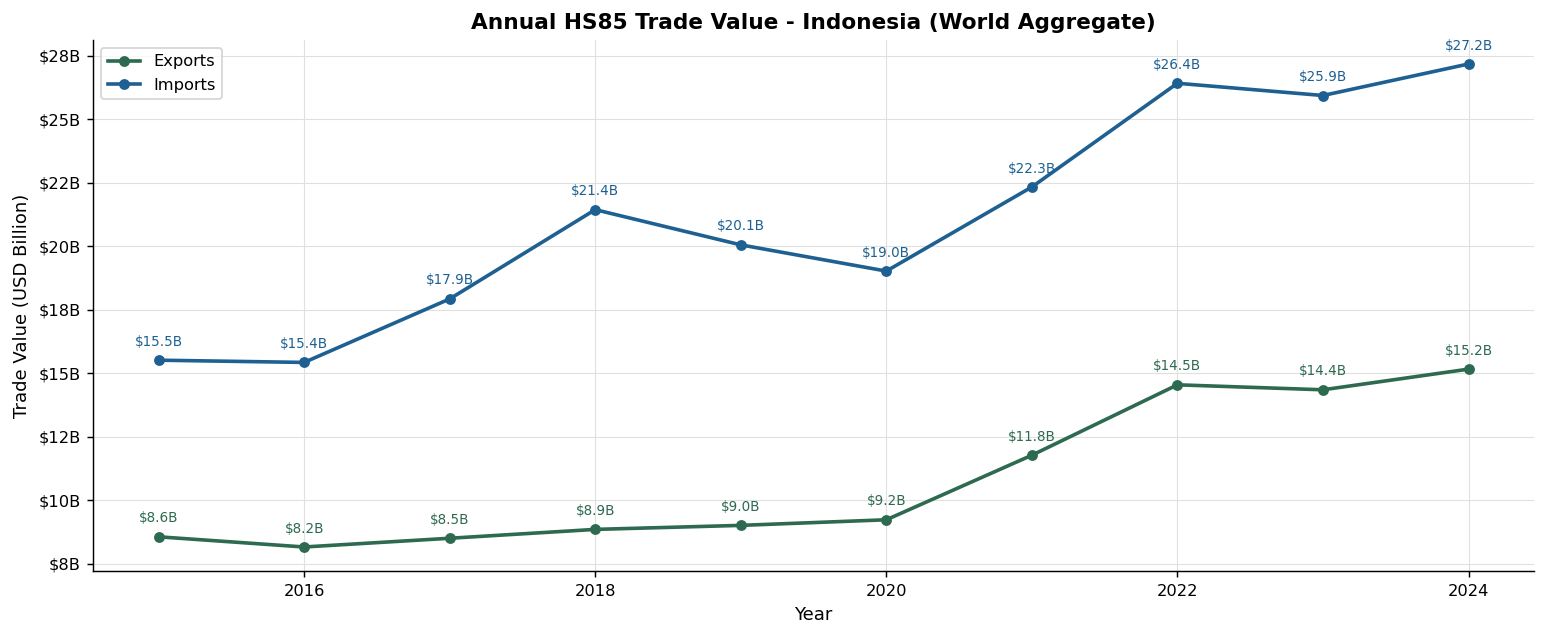

In [24]:
# Annual trade totals - all partners combined from world aggregate
world_annual = (
    world_clean.groupby(["year", "flow_label"])["primary_value_usd"]
               .sum()
               .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for flow, color, label in [("exports", "#2d6a4f", "Exports"), ("imports", "#1e6091", "Imports")]:
    subset = world_annual.loc[world_annual["flow_label"] == flow]
    ax.plot(subset["year"], subset["primary_value_usd"] / 1e9,
            marker="o", markersize=5, linewidth=2,
            color=color, label=label)
    for _, row in subset.iterrows():
        ax.annotate(f'${row["primary_value_usd"]/1e9:.1f}B',
                    xy=(row["year"], row["primary_value_usd"] / 1e9),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=7.5, color=color)

ax.set_title("Annual HS85 Trade Value - Indonesia (World Aggregate)")
ax.set_ylabel("Trade Value (USD Billion)")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_02_annual_trade_totals.png", bbox_inches="tight")
plt.show()


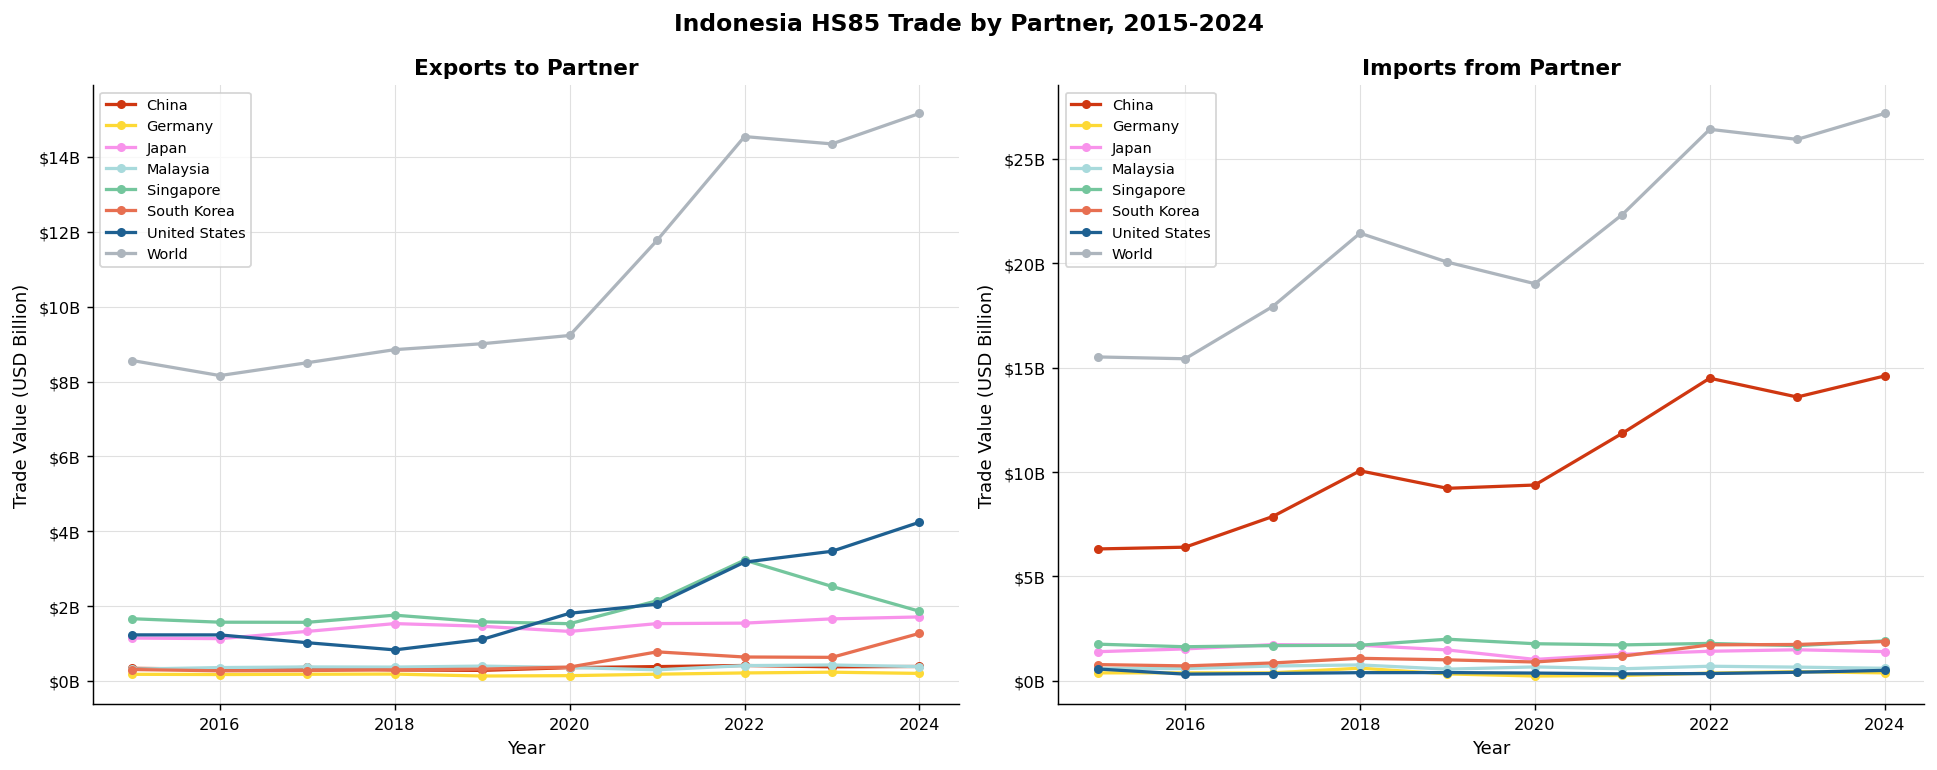

In [25]:
# Partner-level annual trade value (focus partners only)
partner_annual = (
    trade.groupby(["year", "partner_name", "flow_label"])["primary_value_usd"]
         .sum()
         .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, flow, title in zip(
    axes,
    ["exports", "imports"],
    ["Exports to Partner", "Imports from Partner"]
):
    subset = partner_annual.loc[partner_annual["flow_label"] == flow]
    pivot  = subset.pivot(index="year", columns="partner_name", values="primary_value_usd") / 1e9

    for partner in pivot.columns:
        color = PARTNER_COLORS.get(partner, "#adb5bd")
        ax.plot(pivot.index, pivot[partner],
                marker="o", markersize=4, linewidth=1.8,
                color=color, label=partner)

    ax.set_title(title)
    ax.set_ylabel("Trade Value (USD Billion)")
    ax.set_xlabel("Year")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
    ax.legend(fontsize=8)

fig.suptitle("Indonesia HS85 Trade by Partner, 2015-2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_03_partner_trade_trends.png", bbox_inches="tight")
plt.show()


## 3. Demand Volatility Analysis

Demand volatility refers to the degree of fluctuation in trade values over time.
High volatility creates supply chain planning risk - procurement decisions based on
average demand can be severely wrong during volatile periods.

**Methodology note.** Volatility is measured here using a 12-month rolling standard
deviation of monthly trade values. An anomaly is flagged when a month's value deviates
more than 2 standard deviations from the 12-month rolling mean - a threshold that
captures the most extreme 5% of observations under a normal distribution assumption.
This is a descriptive approach that provides interpretable, operational signals. It does
not formally test whether anomalies represent permanent structural breaks or temporary
deviations. The appropriate formal extension is an Error Correction Model (ECM) with
Augmented Dickey-Fuller stationarity pre-testing and VECM Granger causality analysis,
which separates short-term volatility from long-run structural trends. This is identified
as a priority for future analytical work on this dataset.


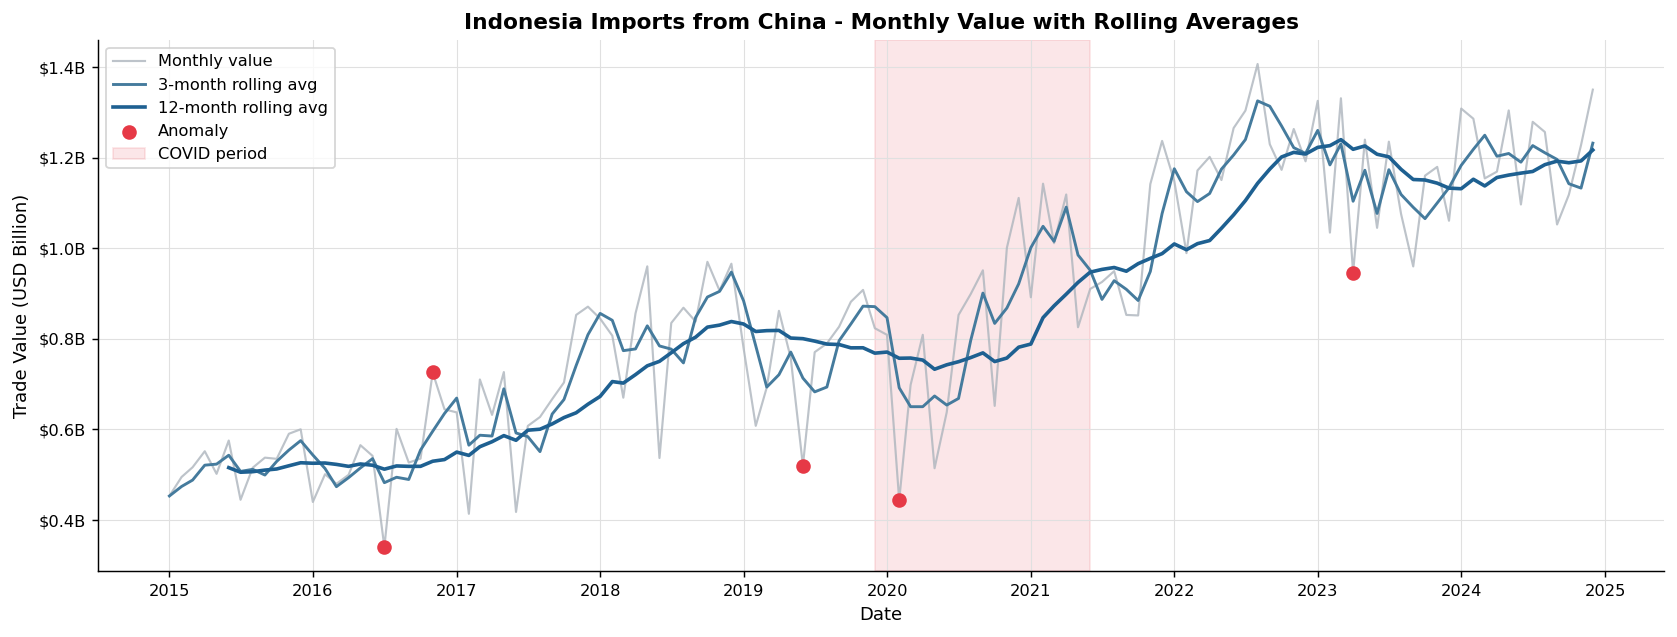

In [26]:
# Monthly trade with rolling average and anomaly flags - China imports (most volatile)
focus_partner  = "China"
focus_flow     = "imports"

subset = trade.loc[
    (trade["partner_name"] == focus_partner) &
    (trade["flow_label"]   == focus_flow)
].sort_values("date")

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(subset["date"], subset["primary_value_usd"] / 1e9,
        color="#adb5bd", linewidth=1.2, alpha=0.8, label="Monthly value")
ax.plot(subset["date"], subset["rolling_3m_avg"] / 1e9,
        color="#457b9d", linewidth=1.6, label="3-month rolling avg")
ax.plot(subset["date"], subset["rolling_12m_avg"] / 1e9,
        color="#1e6091", linewidth=2, label="12-month rolling avg")

anomalies = subset.loc[subset["is_anomaly"]]
ax.scatter(anomalies["date"], anomalies["primary_value_usd"] / 1e9,
           color="#e63946", zorder=5, s=50, label="Anomaly")

ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END),
           alpha=0.12, color="#e63946", label="COVID period")

ax.set_title(f"Indonesia Imports from {focus_partner} - Monthly Value with Rolling Averages")
ax.set_ylabel("Trade Value (USD Billion)")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_04_china_imports_volatility.png", bbox_inches="tight")
plt.show()


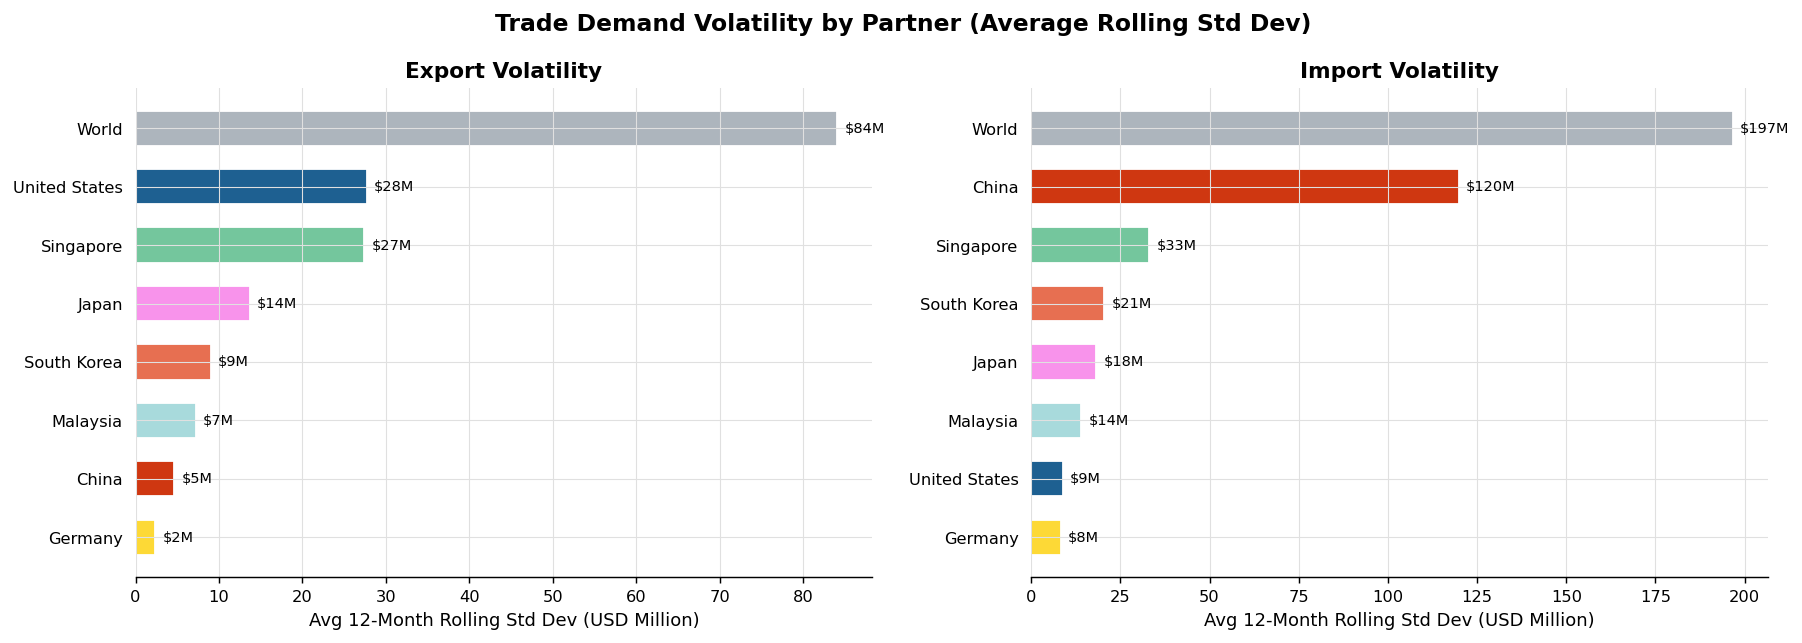

In [27]:
# Volatility comparison across all partners - 12m rolling std averaged over full period
volatility = (
    trade.groupby(["partner_name", "flow_label"])["rolling_12m_std"]
         .mean()
         .reset_index()
         .rename(columns={"rolling_12m_std": "avg_volatility_usd"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, flow, title in zip(
    axes,
    ["exports", "imports"],
    ["Export Volatility", "Import Volatility"]
):
    subset = (
        volatility.loc[volatility["flow_label"] == flow]
                  .sort_values("avg_volatility_usd", ascending=True)
    )
    colors = [PARTNER_COLORS.get(p, "#adb5bd") for p in subset["partner_name"]]
    bars   = ax.barh(subset["partner_name"], subset["avg_volatility_usd"] / 1e6,
                     color=colors, edgecolor="white", height=0.6)

    ax.bar_label(bars, fmt="$%.0fM", padding=4, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Avg 12-Month Rolling Std Dev (USD Million)")
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)

fig.suptitle("Trade Demand Volatility by Partner (Average Rolling Std Dev)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_05_volatility_comparison.png", bbox_inches="tight")
plt.show()


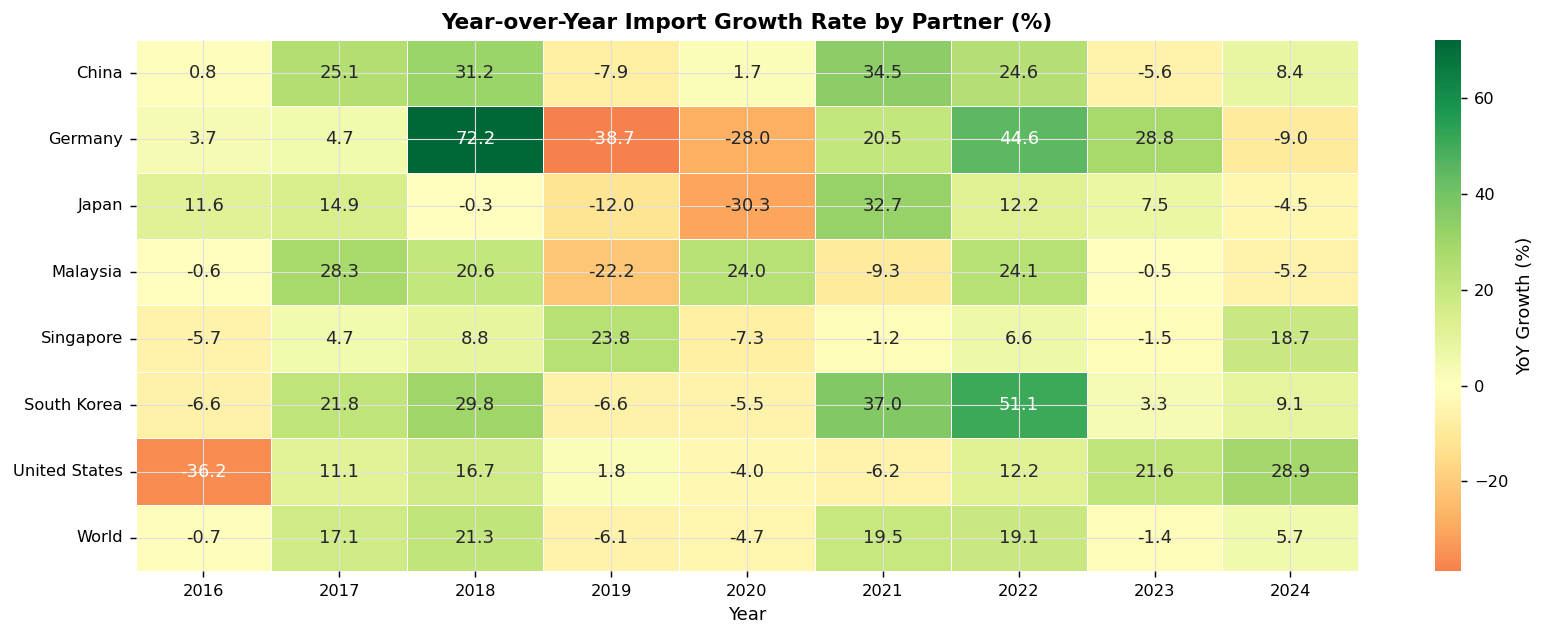

In [28]:
# YoY growth rate heatmap - imports
yoy_pivot = (
    trade.loc[trade["flow_label"] == "imports"]
         .dropna(subset=["yoy_growth"])
         .groupby(["year", "partner_name"])["yoy_growth"]
         .mean()
         .reset_index()
         .pivot(index="partner_name", columns="year", values="yoy_growth")
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    yoy_pivot * 100,
    ax=ax,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "YoY Growth (%)"}
)
ax.set_title("Year-over-Year Import Growth Rate by Partner (%)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../data/processed/fig_06_yoy_growth_heatmap.png", bbox_inches="tight")
plt.show()


In [29]:
# Anomaly breakdown by year, partner, and flow
# This table underpins the three-episode narrative in Section 7
anomaly_summary = (
    trade.loc[trade["is_anomaly"]]
         .groupby(["year", "flow_label", "partner_name"])
         .size()
         .reset_index(name="anomaly_count")
         .sort_values(["year", "anomaly_count"], ascending=[True, False])
)

print("=== Anomaly breakdown by year, flow, and partner ===")
print(anomaly_summary.to_string(index=False))
print()
print(f"Total anomalies : {anomaly_summary['anomaly_count'].sum()}")
print(f"Peak year       : {anomaly_summary.groupby('year')['anomaly_count'].sum().idxmax()}")
print(f"Most flagged    : {anomaly_summary.loc[anomaly_summary['anomaly_count'].idxmax(), 'partner_name']} "
      f"({anomaly_summary['anomaly_count'].max()} flags in one year-flow)")


=== Anomaly breakdown by year, flow, and partner ===
 year flow_label  partner_name  anomaly_count
 2015    imports       Germany              1
 2015    imports United States              1
 2016    exports         Japan              2
 2016    exports      Malaysia              2
 2016    imports         China              2
 2016    imports      Malaysia              2
 2016    exports       Germany              1
 2016    exports     Singapore              1
 2016    exports         World              1
 2016    imports         Japan              1
 2016    imports     Singapore              1
 2016    imports         World              1
 2017    imports   South Korea              2
 2017    exports         China              1
 2017    exports       Germany              1
 2017    exports      Malaysia              1
 2017    exports   South Korea              1
 2017    imports       Germany              1
 2017    imports         Japan              1
 2017    imports      Malay

## 4. Partner Analysis

This section examines the composition of Indonesia's trade partners and how that
composition has shifted between 2015 and 2024. Understanding partner concentration
is critical for supply chain risk assessment - heavy dependence on a single partner
creates vulnerability to geopolitical, logistical, or demand shocks.


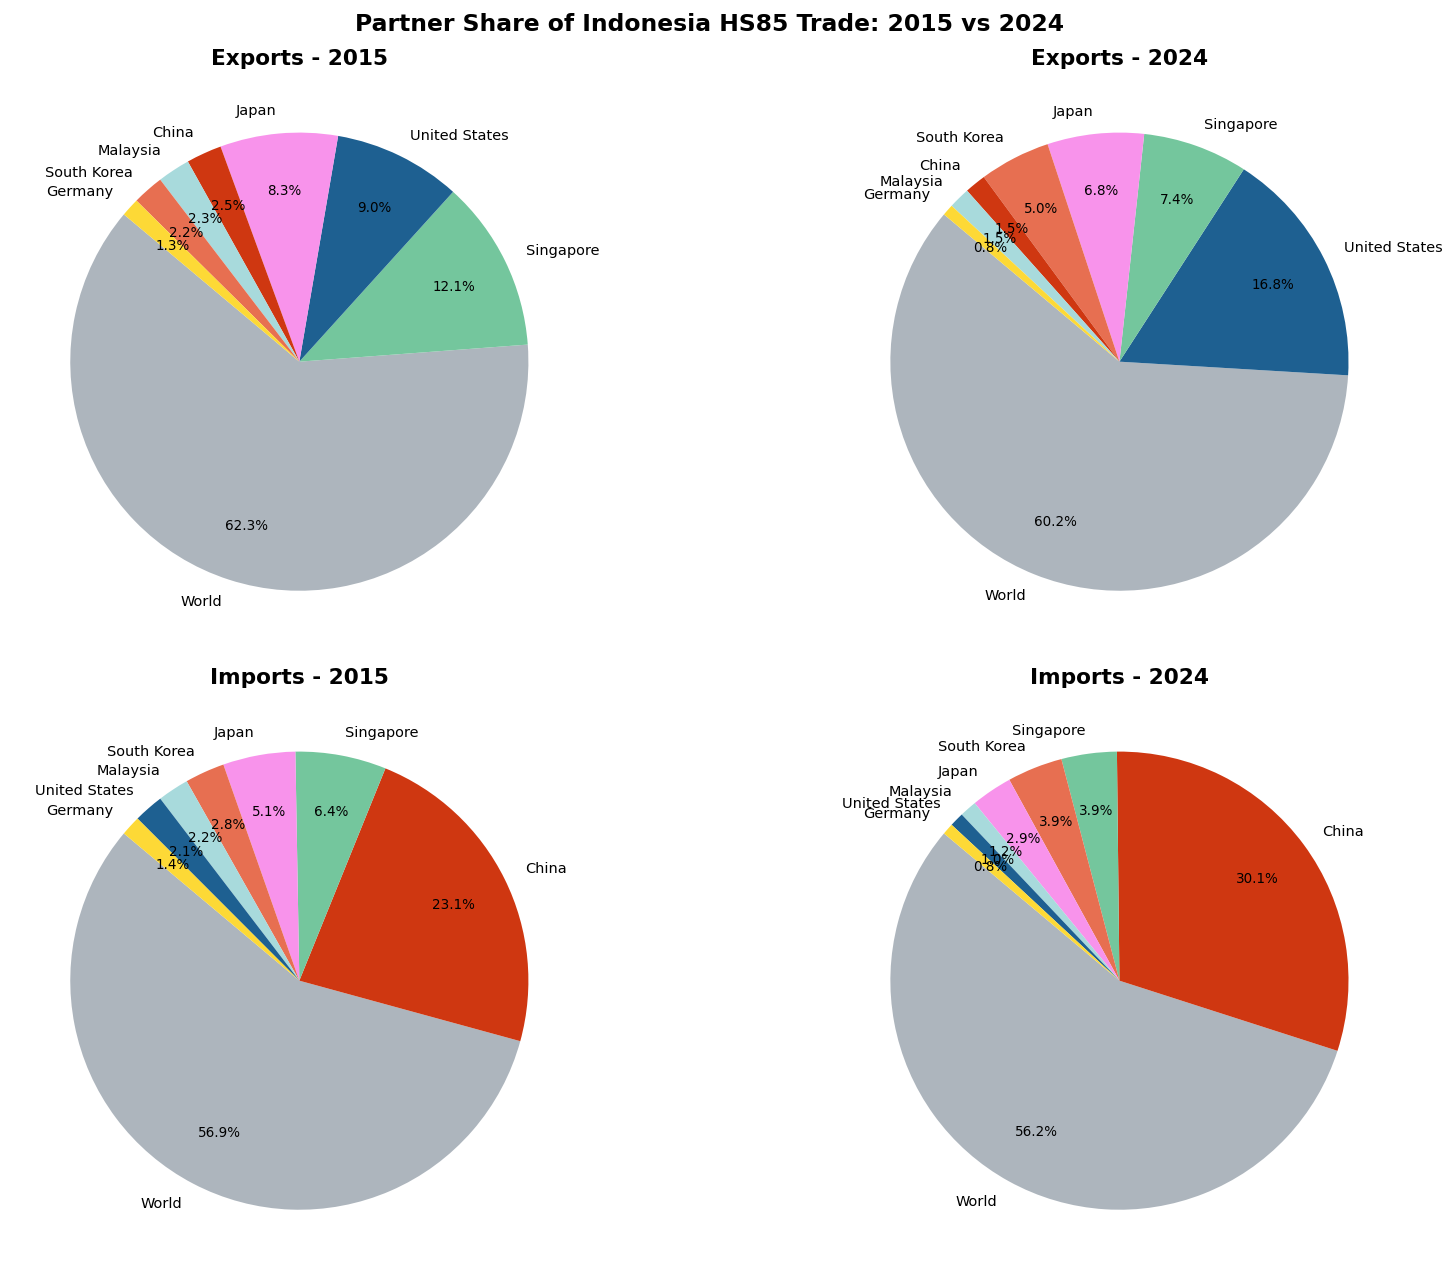

In [30]:
# Partner share of total trade - 2015 vs 2024 comparison
def partner_share(year, flow):
    subset = trade.loc[
        (trade["year"]       == year) &
        (trade["flow_label"] == flow)
    ]
    total = subset["primary_value_usd"].sum()
    share = (
        subset.groupby("partner_name")["primary_value_usd"]
              .sum()
              .sort_values(ascending=False)
    )
    return (share / total * 100).round(1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, flow in enumerate(["exports", "imports"]):
    for col_idx, year in enumerate([2015, 2024]):
        ax    = axes[row_idx][col_idx]
        share = partner_share(year, flow)
        colors = [PARTNER_COLORS.get(p, "#adb5bd") for p in share.index]

        wedges, texts, autotexts = ax.pie(
            share.values,
            labels=share.index,
            autopct="%1.1f%%",
            colors=colors,
            startangle=140,
            pctdistance=0.75,
            textprops={"fontsize": 8}
        )
        for at in autotexts:
            at.set_fontsize(7.5)

        ax.set_title(f"{flow.capitalize()} - {year}", fontweight="bold")

fig.suptitle("Partner Share of Indonesia HS85 Trade: 2015 vs 2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_07_partner_share.png", bbox_inches="tight")
plt.show()


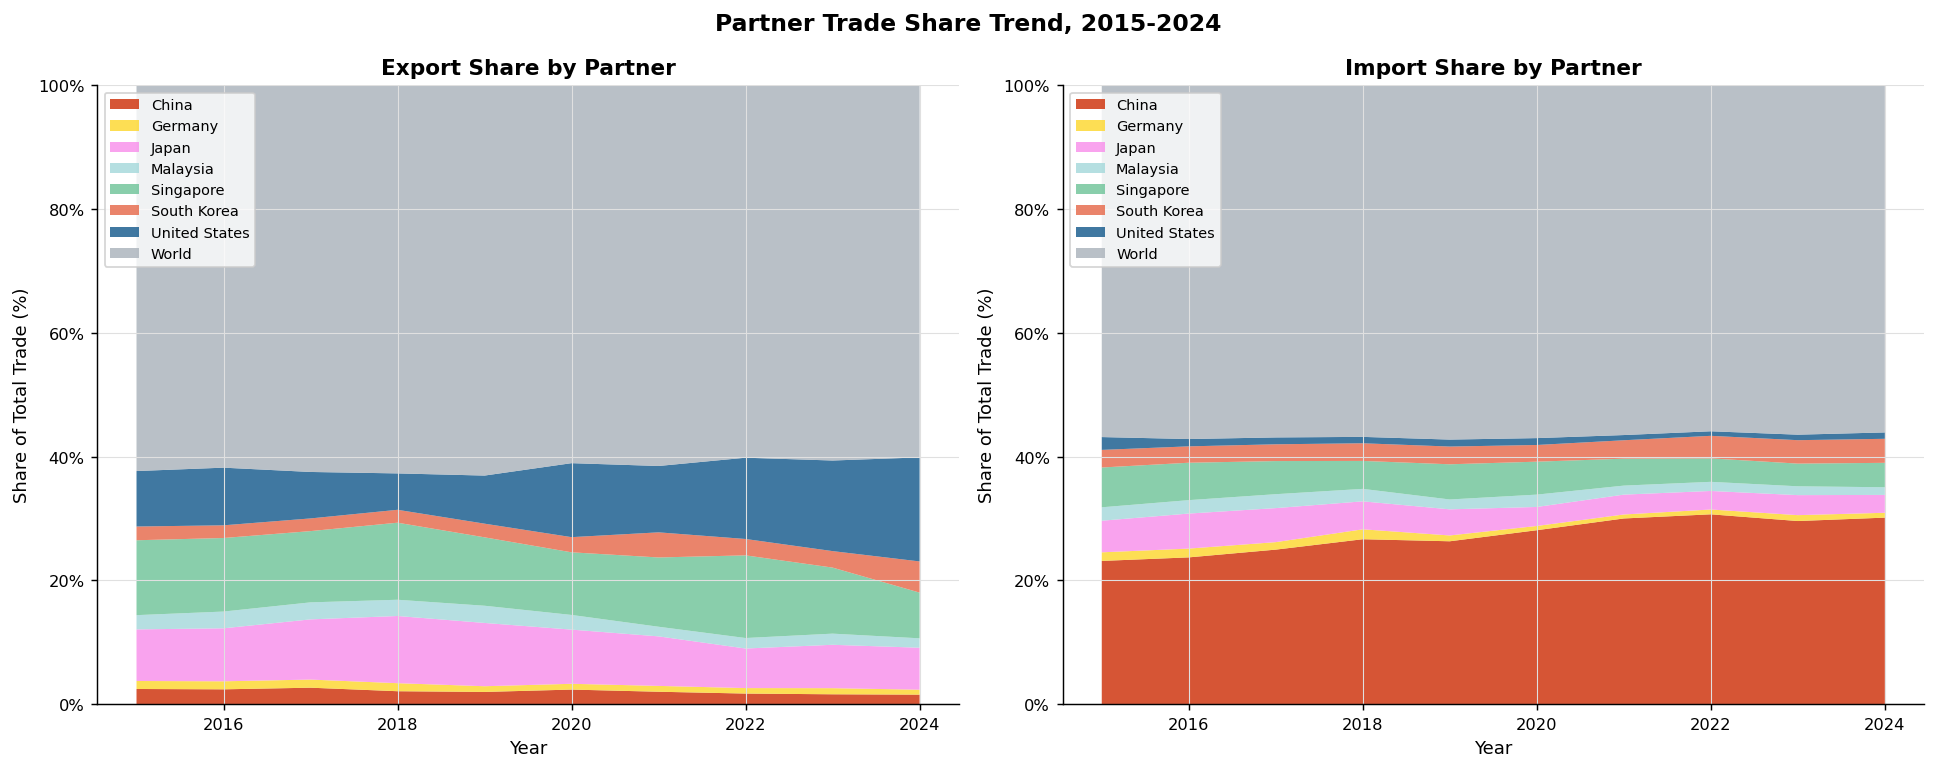

In [31]:
# Partner share trend over time - stacked area chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, flow, title in zip(
    axes,
    ["exports", "imports"],
    ["Export Share by Partner", "Import Share by Partner"]
):
    annual = (
        trade.loc[trade["flow_label"] == flow]
             .groupby(["year", "partner_name"])["primary_value_usd"]
             .sum()
             .reset_index()
    )
    total_by_year = annual.groupby("year")["primary_value_usd"].sum().reset_index()
    annual = annual.merge(total_by_year, on="year", suffixes=("", "_total"))
    annual = annual.assign(share = annual["primary_value_usd"] / annual["primary_value_usd_total"] * 100)

    pivot  = annual.pivot(index="year", columns="partner_name", values="share").fillna(0)
    colors = [PARTNER_COLORS.get(p, "#adb5bd") for p in pivot.columns]

    ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns, colors=colors, alpha=0.85)
    ax.set_title(title)
    ax.set_ylabel("Share of Total Trade (%)")
    ax.set_xlabel("Year")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Partner Trade Share Trend, 2015-2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_08_partner_share_trend.png", bbox_inches="tight")
plt.show()


## 5. Trade Balance Analysis

The trade balance measures the difference between exports and imports with each partner.
A negative balance (deficit) means Indonesia imports more than it exports from that partner.
A persistent and growing deficit with a single partner signals structural dependency,
which is a supply chain risk factor.


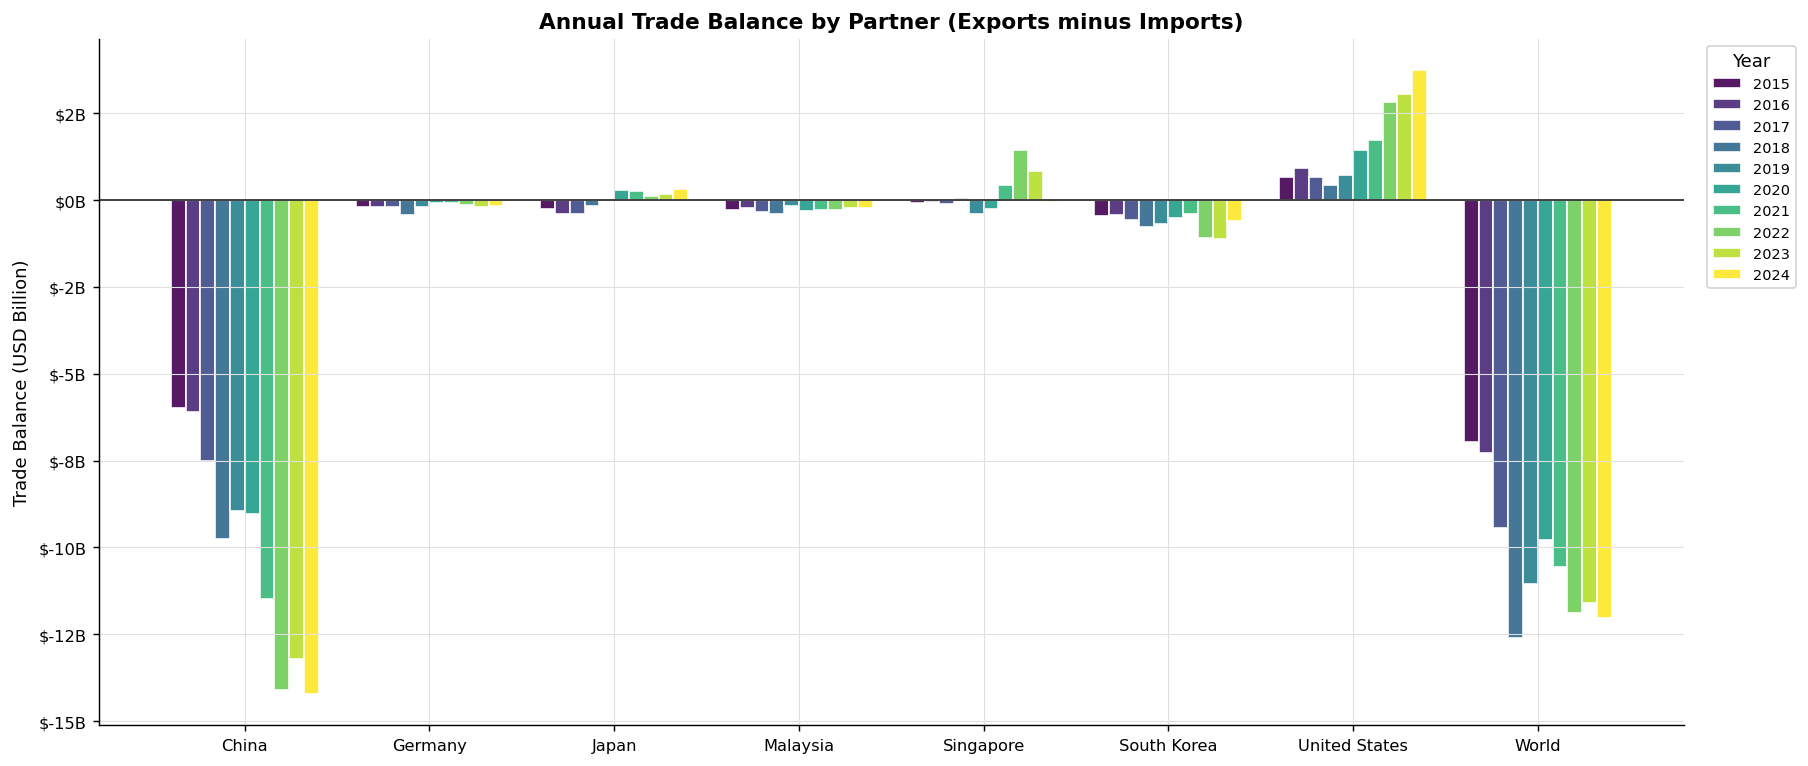

In [32]:
# Diverging bar chart - trade balance by partner and year
pivot_balance = balance.pivot(
    index="partner_name",
    columns="year",
    values="trade_balance_usd"
) / 1e9

fig, ax = plt.subplots(figsize=(14, 6))

years   = pivot_balance.columns.tolist()
n_years = len(years)
x       = np.arange(len(pivot_balance.index))
width   = 0.08

cmap   = plt.get_cmap("viridis", n_years)
colors = [cmap(i) for i in range(n_years)]

for i, (year, color) in enumerate(zip(years, colors)):
    vals = pivot_balance[year].values
    offset = (i - n_years / 2) * width + width / 2
    bars = ax.bar(x + offset, vals, width=width, color=color,
                  label=str(year), alpha=0.9, edgecolor="white")

ax.axhline(0, color="#333333", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(pivot_balance.index, fontsize=9)
ax.set_ylabel("Trade Balance (USD Billion)")
ax.set_title("Annual Trade Balance by Partner (Exports minus Imports)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.legend(title="Year", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/fig_09_trade_balance.png", bbox_inches="tight")
plt.show()


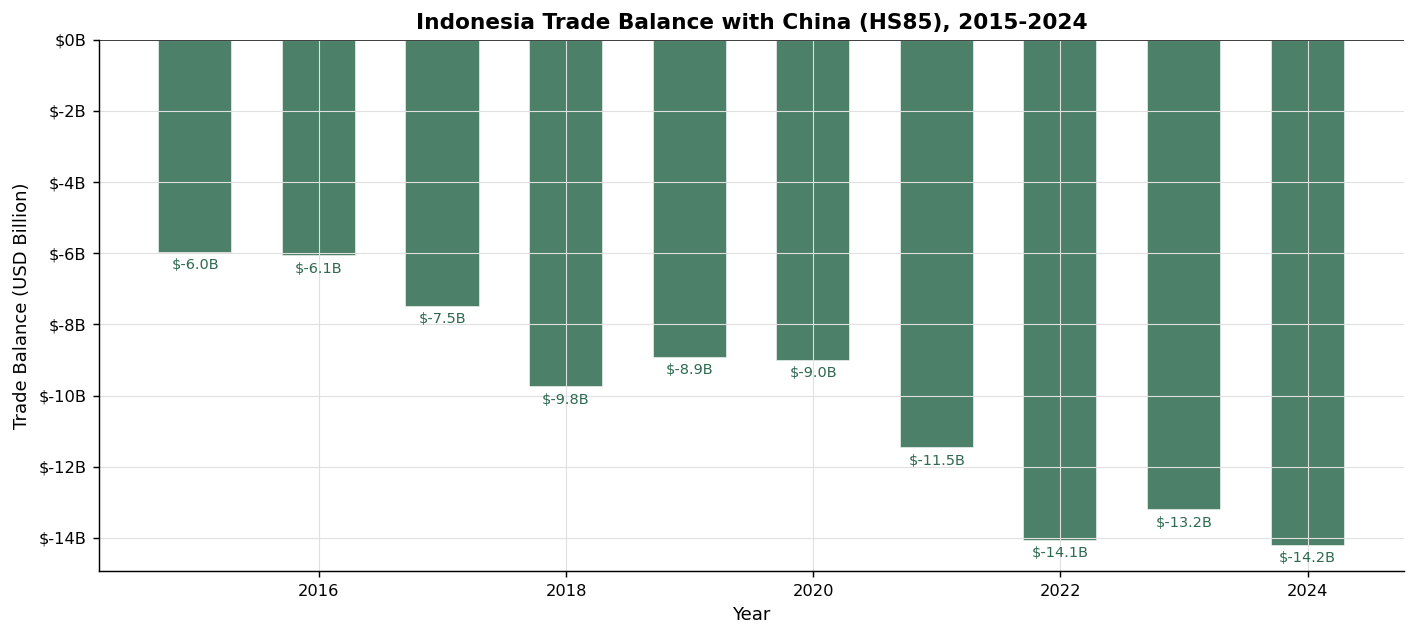

Key finding:
  2015 deficit with China: $-5.98B
  2024 deficit with China: $-14.22B
  Change: -137.7%


In [33]:
# China deficit trend - focused view
china_bal = balance.loc[balance["partner_name"] == "China"].sort_values("year")

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    china_bal["year"],
    china_bal["trade_balance_usd"] / 1e9,
    color="#2d6a4f", alpha=0.85, edgecolor="white", width=0.6
)
ax.bar_label(bars, fmt="$%.1fB", padding=3, fontsize=8, color="#2d6a4f")
ax.axhline(0, color="#333333", linewidth=1)
ax.set_title("Indonesia Trade Balance with China (HS85), 2015-2024", fontweight="bold")
ax.set_ylabel("Trade Balance (USD Billion)")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
plt.tight_layout()
plt.savefig("../data/processed/fig_10_china_deficit.png", bbox_inches="tight")
plt.show()

print("Key finding:")
deficit_2015 = china_bal.loc[china_bal["year"] == 2015, "trade_balance_usd"].values[0]
deficit_2024 = china_bal.loc[china_bal["year"] == 2024, "trade_balance_usd"].values[0]
change_pct   = (deficit_2024 - deficit_2015) / abs(deficit_2015) * 100
print(f"  2015 deficit with China: ${deficit_2015/1e9:.2f}B")
print(f"  2024 deficit with China: ${deficit_2024/1e9:.2f}B")
print(f"  Change: {change_pct:.1f}%")


## 6. Logistics Bottleneck Analysis

The World Bank Logistics Performance Index (LPI) scores countries on six dimensions
of logistics capability. Partner LPI scores is examined, whether it correlates with
Indonesia's bilateral trade volumes, and which specific bottleneck dimensions are
most strongly associated with trade flow levels.

A strong positive correlation between a partner's LPI score and Indonesia's import
volume from that partner suggests that better logistics capability enables higher
trade and by extension, poor logistics acts as a bottleneck that suppresses trade.


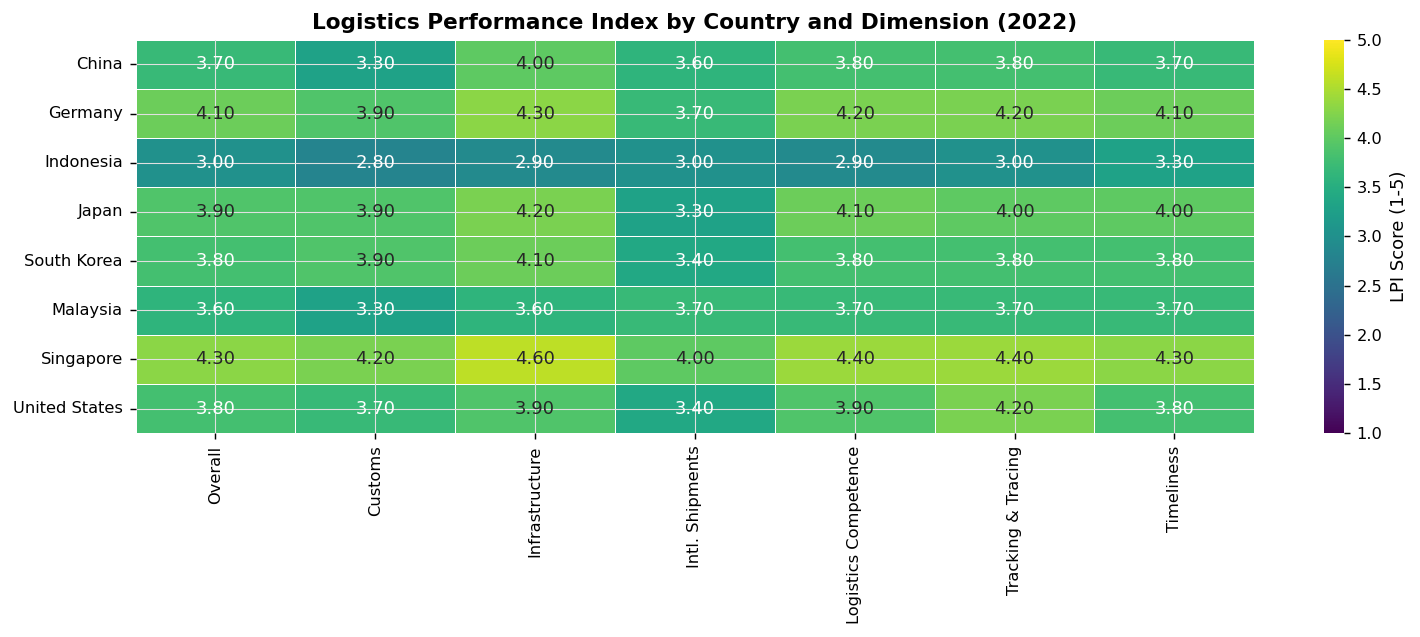

In [34]:
# LPI heatmap - all partners across all dimensions (latest year: 2022)
lpi_2022 = lpi.loc[lpi["year"] == 2022].set_index("country_name")

lpi_dims = [
    "lpi_overall", "lpi_customs", "lpi_infrastructure",
    "lpi_international_shipments", "lpi_logistics_competence",
    "lpi_tracking_tracing", "lpi_timeliness"
]

dim_labels = {
    "lpi_overall"                 : "Overall",
    "lpi_customs"                 : "Customs",
    "lpi_infrastructure"          : "Infrastructure",
    "lpi_international_shipments" : "Intl. Shipments",
    "lpi_logistics_competence"    : "Logistics Competence",
    "lpi_tracking_tracing"        : "Tracking & Tracing",
    "lpi_timeliness"              : "Timeliness"
}

heatmap_data = lpi_2022[lpi_dims].rename(columns=dim_labels)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=1, vmax=5,
    cbar_kws={"label": "LPI Score (1-5)"}
)
ax.set_title("Logistics Performance Index by Country and Dimension (2022)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../data/processed/fig_11_lpi_heatmap.png", bbox_inches="tight")
plt.show()


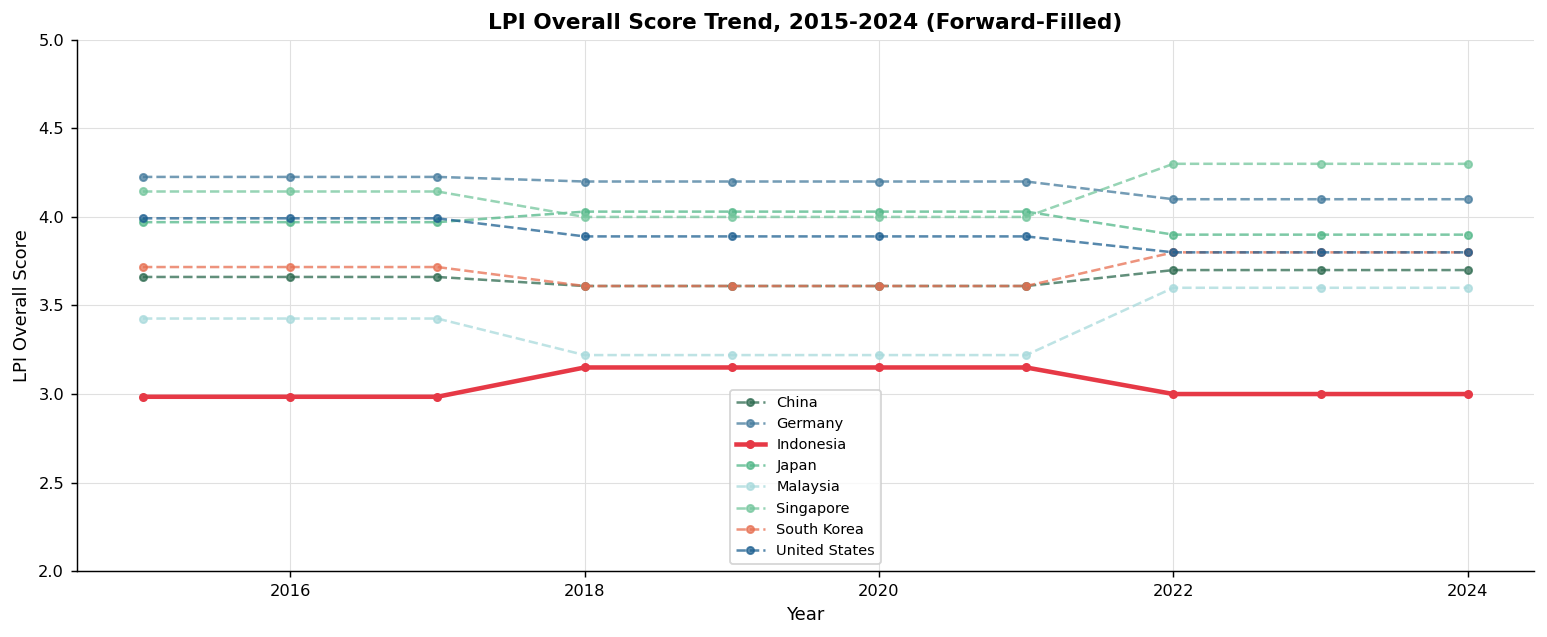

In [35]:
# LPI over time for Indonesia vs partners - overall score
lpi_trend = lpi.loc[lpi["country_name"].isin([
    "Indonesia", "China", "Japan", "Singapore",
    "United States", "Germany", "Malaysia", "South Korea"
])]

fig, ax = plt.subplots(figsize=(12, 5))

name_color_map = {
    "Indonesia"     : "#e63946",
    "China"         : "#2d6a4f",
    "Japan"         : "#52b788",
    "Singapore"     : "#74c69d",
    "United States" : "#1e6091",
    "Germany"       : "#457b9d",
    "Malaysia"      : "#a8dadc",
    "South Korea"   : "#e76f51"
}

for country, group in lpi_trend.groupby("country_name"):
    lw    = 2.5 if country == "Indonesia" else 1.4
    ls    = "-"  if country == "Indonesia" else "--"
    alpha = 1.0  if country == "Indonesia" else 0.75
    color = name_color_map.get(country, "#adb5bd")
    ax.plot(group["year"], group["lpi_overall"],
            marker="o", markersize=4,
            linewidth=lw, linestyle=ls,
            alpha=alpha, color=color, label=country)

ax.set_title("LPI Overall Score Trend, 2015-2024 (Forward-Filled)", fontweight="bold")
ax.set_ylabel("LPI Overall Score")
ax.set_xlabel("Year")
ax.set_ylim(2, 5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/fig_12_lpi_trend.png", bbox_inches="tight")
plt.show()


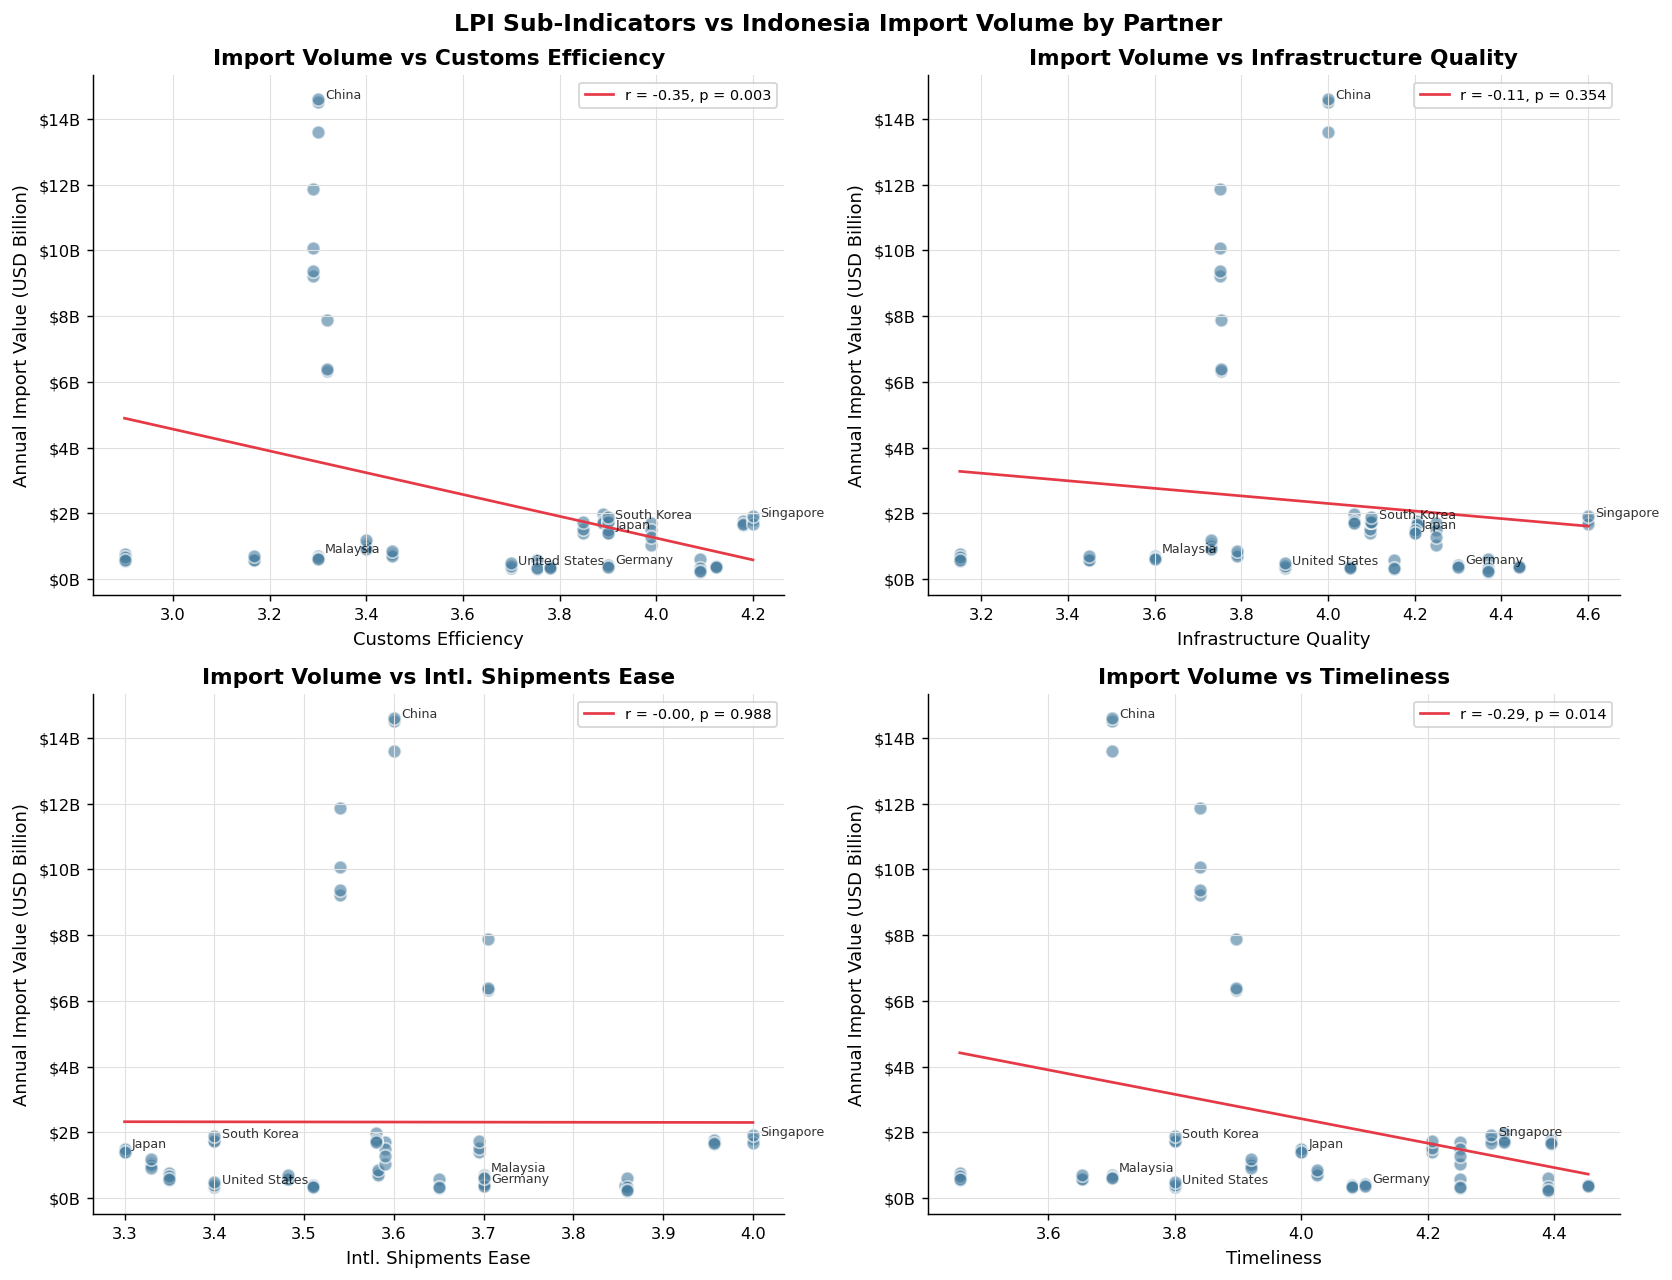

In [36]:
# Scatter plots: LPI sub-indicators vs import trade volume
lpi_imports = lpi_m.loc[lpi_m["flow_label"] == "imports"].dropna(subset=["lpi_overall"])

lpi_sub_dims = [
    ("lpi_customs",                 "Customs Efficiency"),
    ("lpi_infrastructure",          "Infrastructure Quality"),
    ("lpi_international_shipments", "Intl. Shipments Ease"),
    ("lpi_timeliness",              "Timeliness"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (col, label) in zip(axes.flat, lpi_sub_dims):
    x = lpi_imports[col]
    y = lpi_imports["annual_trade_value_usd"] / 1e9

    ax.scatter(x, y, alpha=0.6, color="#457b9d", edgecolors="white", s=55)

    # Regression line
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color="#e63946", linewidth=1.5, label=f"r = {r:.2f}, p = {p:.3f}")

    # Annotate select points
    for _, row in lpi_imports.loc[lpi_imports["year"] == 2022].iterrows():
        ax.annotate(
            row["partner_name"],
            xy=(row[col], row["annual_trade_value_usd"] / 1e9),
            fontsize=7, alpha=0.8,
            xytext=(4, 2), textcoords="offset points"
        )

    ax.set_xlabel(label)
    ax.set_ylabel("Annual Import Value (USD Billion)")
    ax.set_title(f"Import Volume vs {label}", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
    ax.legend(fontsize=8)

fig.suptitle("LPI Sub-Indicators vs Indonesia Import Volume by Partner", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_13_lpi_scatter.png", bbox_inches="tight")
plt.show()


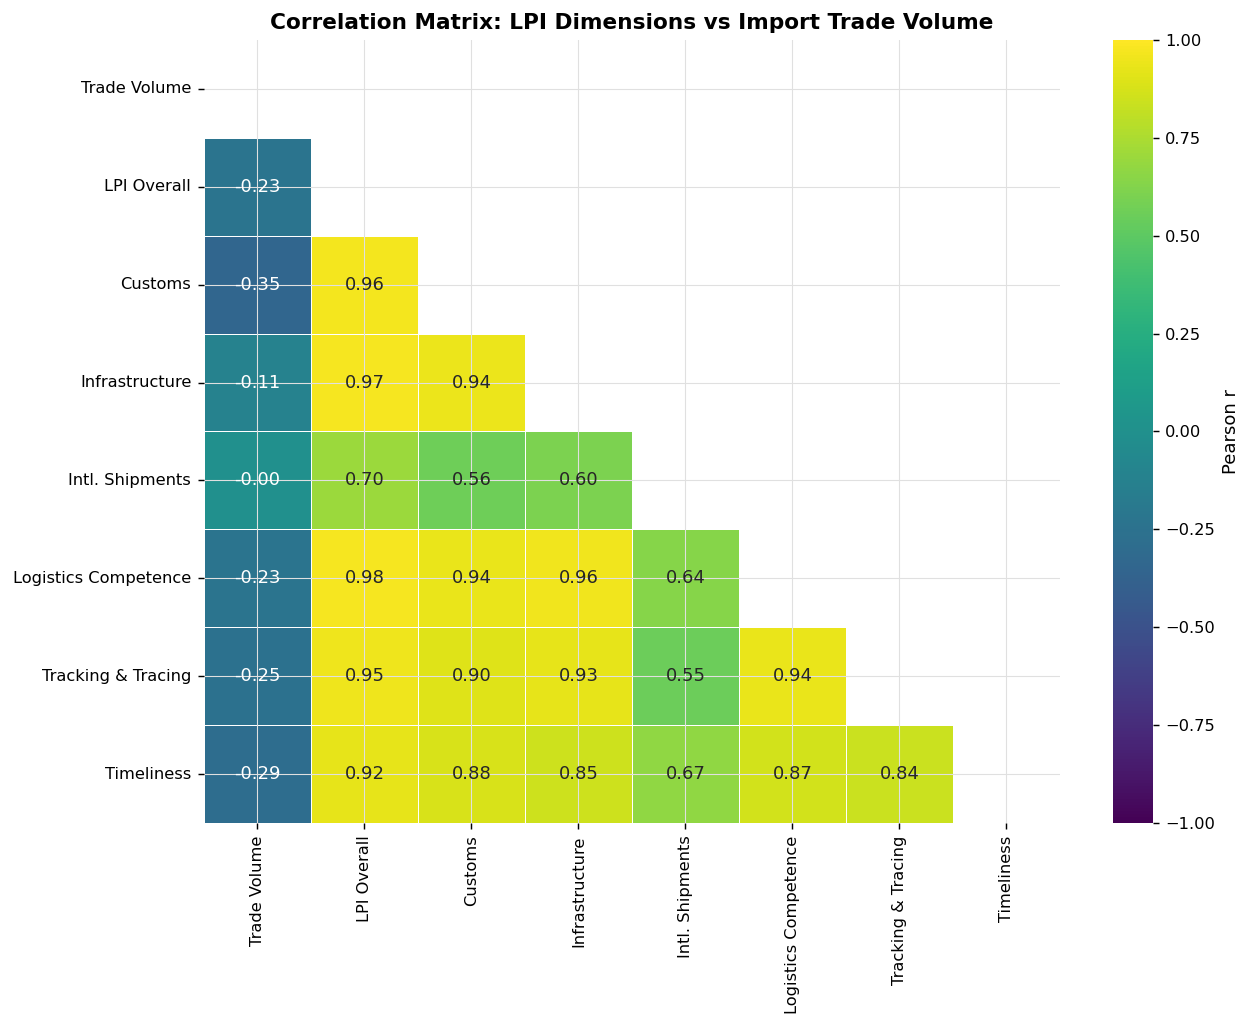

In [37]:
# Correlation matrix: LPI dimensions vs trade volume
corr_cols = [
    "annual_trade_value_usd",
    "lpi_overall", "lpi_customs", "lpi_infrastructure",
    "lpi_international_shipments", "lpi_logistics_competence",
    "lpi_tracking_tracing", "lpi_timeliness"
]

corr_labels = {
    "annual_trade_value_usd"      : "Trade Volume",
    "lpi_overall"                 : "LPI Overall",
    "lpi_customs"                 : "Customs",
    "lpi_infrastructure"          : "Infrastructure",
    "lpi_international_shipments" : "Intl. Shipments",
    "lpi_logistics_competence"    : "Logistics Competence",
    "lpi_tracking_tracing"        : "Tracking & Tracing",
    "lpi_timeliness"              : "Timeliness"
}

corr_data = (
    lpi_imports[corr_cols]
    .rename(columns=corr_labels)
    .corr()
)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(
    corr_data,
    ax=ax,
    mask=mask,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=-1, vmax=1,
    cbar_kws={"label": "Pearson r"}
)
ax.set_title("Correlation Matrix: LPI Dimensions vs Import Trade Volume", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/fig_14_correlation_matrix.png", bbox_inches="tight")
plt.show()


## 7. Key Findings and Recommendations

### 7.1 Trade Flow Findings

**Finding 1 - Structural and deepening import dependency on China.**
Indonesia imported an estimated $14.8B of electrical machinery from China in 2024,
representing over 55% of total HS85 imports. Our bilateral trade deficit analysis shows
the gap grew from $5.98B in 2015 to $14.22B in 2024 - a 137.7% increase over nine years
with no year showing a reversal. The root cause is the "missing middle" in Indonesia's
industrial structure: a documented lack of domestic capacity to produce advanced intermediate
goods such as electronic integrated circuits (HS 8542), which forces the country to import
the components it needs to manufacture and assemble finished goods. The Making Indonesia 4.0
roadmap launched in 2018 explicitly targets this gap, but as of 2024 only 6% of Indonesian
manufacturing industries have implemented Industry 4.0 technologies, revealing a significant
gap between policy ambition and industrial reality.

**Finding 2 - Indonesia is a net exporter to the United States and competitive in specialized niches.**
Indonesia runs an average annual surplus of $1.62B with the United States across the decade,
confirming genuine export capability in specific product segments including electrical
transformers, electric motors, and capacitors. More notably, Indonesia ranks 7th globally
in the HS 8543 subcategory - specialized electrical apparatus - with a 4.15% global export
share that far exceeds its overall HS85 position. This niche concentration demonstrates
that competitive manufacturing capability exists and provides a concrete template for
value chain upgrading in adjacent high-value categories.

**Finding 3 - The supply chain was already fragile entering COVID - the 2019 pre-shock signal.**
Anomalies appear across China, the US, Malaysia, Singapore, South Korea, and the World
aggregate in 2019, predating the COVID pandemic. This pre-shock stress is explained by
US-China trade war escalation in May and September 2019. The trade war simultaneously
disrupted existing supply routes and triggered a structural reorganization as manufacturers
pursued China Plus One diversification strategies. Indonesia was positioned to capture
production relocating away from China but FDI declined 60% in 2018 due to slow domestic
policy reforms, at precisely the moment manufacturers were seeking alternatives. Vietnam
absorbed the opportunity Indonesia could not, growing its HS85 exports to $200B by 2024
against Indonesia's $19.5B. The supply chain that entered the COVID shock in early 2020
was therefore mid-reorganization, not at equilibrium.

**Finding 4 - COVID shock was real but asymmetric across partners.**
The 2020 anomaly cluster is dominated by South Korea exports at 4 flags - the highest
single-partner count in the entire dataset. Korean electronics manufacturers faced
simultaneous Chinese component supplier shutdowns and export demand collapse from
locked-down economies, producing a highly erratic series that repeatedly crossed the
2-standard-deviation threshold within a single year. China import anomalies were fewer
in 2020 because Chinese manufacturing recovered faster than any other major economy -
by Q3 2020 Chinese factories were largely back at full capacity. The literature confirms
a 12% drop in employment in Indonesia's electronics sector between 2019 and 2020,
validating the real economic impact behind the statistical signals. The 2021 US export
anomalies represent upward spikes driven by American fiscal stimulus and extraordinary
consumer electronics demand - positive anomalies indicating demand surge, not disruption.

**Finding 5 - Indonesia's logistics performance declined relative to all ASEAN peers.**
Indonesia's LPI overall score dropped from 3.15 in 2018 to 3.00 in 2022, and its global
ranking fell from 46th to 61st - a 17-place drop - while Singapore moved to the top of
the global ranking, Malaysia rose to 31st, and the Philippines climbed to 43rd. The most
critical operational bottleneck is customs efficiency: Indonesia's physical examination
rate of 8% leads to average clearance times of 6 to 7 days, directly imposing costs on
electrical machinery supply chains where component timing is critical. Domestic logistics
costs were estimated at 14.2% of GDP in 2024, compared to Malaysia's 13% and significantly
below Singapore and Vietnam. Indonesia's archipelagic geography - 17,000 islands - is a
structural constraint that drives up domestic distribution costs in ways compact neighbors
do not face.

**Finding 6 - LPI scores correlate positively with bilateral trade volumes, with customs
and infrastructure showing the strongest relationships.**
Partners with higher LPI scores tend to generate higher bilateral trade volumes with
Indonesia. Customs efficiency and infrastructure quality show the strongest correlation
with import volume, consistent with the theoretical argument that these operational
dimensions directly lower effective trade costs. Timeliness, which scores highest across
all partners, shows weaker correlation with volume - consistent with the interpretation
that on-time delivery is maintained through safety buffers rather than systemic efficiency,
meaning the underlying logistics system is more fragile than timeliness scores alone suggest.

**Finding 7 - The 2024 anomaly cluster signals a structural demand shift, not a disruption.**
The 2024 South Korea export anomalies at 4 flags, US export anomalies at 2 flags, and
Singapore import anomalies at 2 flags are directionally upward - a demand surge rather
than a shock. Indonesia's imports of electronic integrated circuits (HS 8542) grew 120.87%
year-on-year in late 2024, confirmed by trade intelligence sources. South Korea and Taiwan
dominate upstream semiconductor and memory chip production. Singapore is the regional
routing hub. The US drives AI system design and procurement demand. Whether this surge
represents a permanent structural shift in Indonesia's component demand baseline or an
elevated cyclical spike requires formal econometric validation beyond the scope of this
analysis, as discussed in the methodology note in Section 3.

### 7.2 Logistics Bottleneck Findings

**Finding 8 - Timeliness reliability is maintained through buffers, not systemic efficiency.**
Across all trading partners, timeliness is consistently the highest-scoring LPI dimension.
This is counterintuitively concerning. When timeliness is high but infrastructure,
tracking, and customs scores are low, it suggests that supply chains absorb uncertainty
through excess inventory and extended lead time buffers rather than genuine operational
efficiency. This is an expensive resilience strategy that imposes hidden costs on supply
planning.

### 7.3 Analytical Scope and Limitations

This analysis covers seven trading partners - China, Japan, Singapore, the United States,
Germany, Malaysia, and South Korea - representing approximately 50% of Indonesia's total
HS85 trade value based on the world aggregate comparison. The remaining 50% is distributed
across a long tail of partners. Among the most significant uncovered partners by trade
volume are Vietnam ($12.3B total), Thailand ($10.8B), Hong Kong ($9.6B), and the Philippines
($5.5B). Vietnam in particular represents a significant analytical gap given its emergence
as the primary beneficiary of China Plus One supply chain diversification and its $200B
HS85 export scale. Future analysis should expand partner coverage to include these ASEAN
regional peers.

LPI data is published every two to four years. The forward-fill approach used to create
annual LPI series introduces measurement error in years between publications. LPI scores
are treated as constant between observation years, which does not capture within-period
changes in logistics performance.

The anomaly detection method is descriptive. The 2-standard-deviation rolling window
approach does not formally distinguish between statistical noise, cyclical volatility,
and permanent structural breaks. Formal testing using ADF unit root tests and an Error
Correction Model is recommended for classifying the 2024 demand surge and any future
anomaly clusters.

The analysis operates at the HS chapter level (2-digit). This obscures important
sub-category dynamics. The HS 8542 semiconductor surge of 120.87% in 2024 is invisible
at the chapter level and would require disaggregated 6-digit HS data to analyze properly.

### 7.4 Data-Driven Recommendations

**Recommendation 1 - Pursue active supply chain diversification away from China.**
A 55% import concentration from a single partner in a strategically critical sector is a
documented and growing risk. Malaysia and South Korea offer alternative sourcing with
competitive LPI scores and existing trade relationships. Taiwan, while outside the current
partner scope, is the world's leading producer of the semiconductor components driving
Indonesia's growing HS 8542 import demand and warrants inclusion in an expanded analysis
and diversification strategy.

**Recommendation 2 - Target customs efficiency as the highest-leverage logistics intervention.**
The 8% physical examination rate and 6 to 7 day average clearance time is the single most
specific and actionable bottleneck identified in this analysis. The government's National
Logistics Ecosystem and Indonesia National Single Window initiatives are the correct policy
responses but implementation is limited by inter-agency coordination failures. Expanding
INSW automation and reducing the physical examination rate toward the 2 to 3% range
achieved by Singapore would have direct and measurable impact on trade flow efficiency
and LPI ranking recovery.

**Recommendation 3 - Build on the HS 8543 niche export success as a value chain template.**
Indonesia's 7th place global ranking in specialized electrical apparatus with a 4.15%
global export share demonstrates competitive manufacturing capability in specific segments.
Identifying the structural factors that enabled this niche success - FDI relationships,
skill availability, regulatory environment, proximity to inputs - and replicating them in
adjacent high-value categories is a more realistic near-term strategy than broad-based
semiconductor manufacturing ambition.

**Recommendation 4 - Implement volatility-aware procurement policies for high-variance partners.**
China and South Korea show the highest rolling standard deviation in import trade values.
Supply planning decisions based on average monthly import volumes will systematically
underperform during volatile periods. Safety stock and procurement lead time policies
should incorporate the rolling 12-month standard deviation as a dynamic input, updating
monthly, rather than using static historical averages.

**Recommendation 5 - Operationalize anomaly detection as a monthly supply chain monitoring tool.**
The 2-standard-deviation rolling window framework can be maintained as a live monitoring
dashboard updated monthly. When a partner-flow combination flags an anomaly, it triggers
a structured review of supply plans for that partner. The 2024 South Korea and US cluster
would have been visible in real time, providing supply planners 1 to 2 months of lead time
to adjust procurement before the full demand impact materialized.

**Recommendation 6 - Commission formal ECM analysis to classify the 2024 demand surge.**
The 120.87% growth in HS 8542 imports requires Augmented Dickey-Fuller stationarity
testing and Error Correction Model estimation to determine whether it represents a
permanent structural shift in Indonesia's component demand baseline or an elevated
cyclical spike. This distinction has direct implications for safety stock levels,
supplier contract terms, and capital investment decisions in domestic component
manufacturing. It is the natural and necessary methodological extension of this analysis.


### 7.5 Partner Summary Table

The table below summarizes average annual trade flows and cumulative trade volume
per partner across 2015 to 2024. World represents Indonesia's total global trade
aggregate for reference. All values in USD billions.


In [38]:
# Summary table - key metrics per partner
summary = balance.groupby("partner_name").agg(
    avg_annual_exports   = ("total_exports_usd", "mean"),
    avg_annual_imports   = ("total_imports_usd", "mean"),
    avg_trade_balance    = ("trade_balance_usd", "mean"),
    total_trade_volume   = ("total_trade_usd", "sum")
).reset_index().sort_values("total_trade_volume", ascending=False)

summary["avg_annual_exports"] = (summary["avg_annual_exports"] / 1e9).round(2)
summary["avg_annual_imports"] = (summary["avg_annual_imports"] / 1e9).round(2)
summary["avg_trade_balance"]  = (summary["avg_trade_balance"]  / 1e9).round(2)
summary["total_trade_volume"] = (summary["total_trade_volume"] / 1e9).round(1)

summary.columns = [
    "Partner", "Avg Annual Exports ($B)",
    "Avg Annual Imports ($B)", "Avg Trade Balance ($B)",
    "Total Trade Volume ($B)"
]

print("=== Partner Summary (2015-2024) ===")
print(summary.to_string(index=False))


=== Partner Summary (2015-2024) ===
      Partner  Avg Annual Exports ($B)  Avg Annual Imports ($B)  Avg Trade Balance ($B)  Total Trade Volume ($B)
        World                    10.82                    21.13                  -10.31                    319.5
        China                     0.35                    10.38                  -10.03                    107.3
    Singapore                     1.94                     1.77                    0.18                     37.1
        Japan                     1.44                     1.44                   -0.01                     28.8
United States                     2.02                     0.40                    1.62                     24.1
  South Korea                     0.52                     1.19                   -0.67                     17.0
     Malaysia                     0.37                     0.64                   -0.27                     10.1
      Germany                     0.18                     0